In [1]:
!pip install scikit-learn pandas matplotlib

In [2]:
# --- Cell 1: Imports and setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Make plots display inline
%matplotlib inline

In [3]:
# --- Cell 2: Load a dataset ---
# Use the famous Iris dataset for demonstration
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

print("First few rows:")
df.head()


First few rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# --- Cell 3: Basic analysis ---
print("Dataset shape:", df.shape)
print("\nSpecies distribution:")
print(df['species'].value_counts())

# Quick summary statistics
df.describe()


Dataset shape: (150, 5)

Species distribution:
species
0    50
1    50
2    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


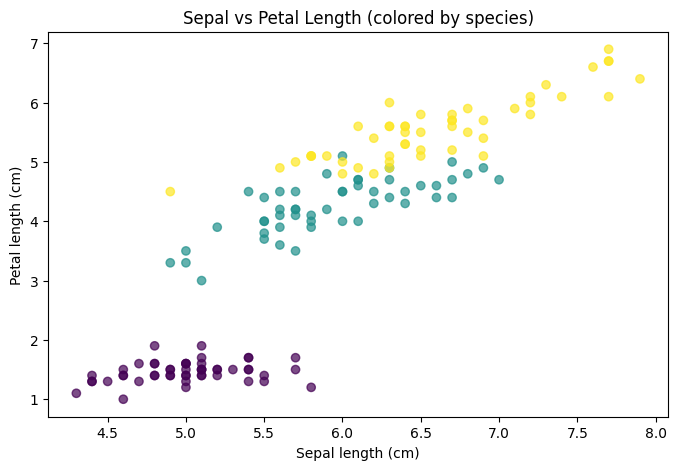

In [8]:
# --- Cell 4: Data visualization ---
plt.figure(figsize=(8,5))
plt.scatter(df['sepal length (cm)'], df['petal length (cm)'],
            c=df['species'], cmap='viridis', alpha=0.7)
plt.title('Sepal vs Petal Length (colored by species)')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')
plt.show()


In [5]:
# --- Cell 5: Train/test split + model training ---
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
accuracy = accuracy_score(y_test, preds)

print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 100.00%


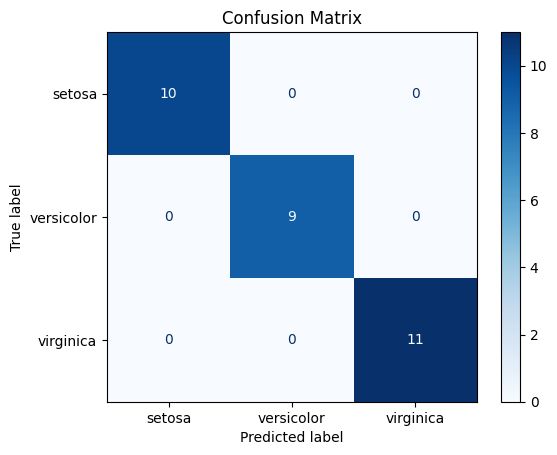

In [10]:
# --- Cell 6: Confusion matrix visualization ---
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()


In [6]:
# --- Cell 8: Predict interactively ---
sample = X_test.sample(1, random_state=1)
prediction = model.predict(sample)[0]
print("Sample input:")
display(sample)
print(f"Predicted species: {iris.target_names[prediction]}")


Sample input:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
69,5.6,2.5,3.9,1.1


Predicted species: versicolor
